# 98 - 総合まとめと推奨: 顔認識ベクトルへの ITQ-LSH 適用

このノートブックは NB91〜97 シリーズの総合まとめです。ArcFace 512次元埋め込みに対する ITQ-LSH（Iterative Quantization - Locality Sensitive Hashing）の適用可能性を多角的に分析した結果を整理し、実用上の推奨構成を提示します。

## 実験シリーズ概要

| NB | テーマ | 主な成果 |
|---|---|---|
| 91 | 顔Embeddingの空間特性分析 | 異方性、コサイン類似度分布、PCA可視化 |
| 92 | ITQ学習とハッシュ品質評価 | ビット数比較（64/96/128/256）、SimHash対比 |
| 93 | カスケード検索精度評価 | HNSW vs ITQ-LSH の Recall@K 比較 |
| 94 | ITQ超平面の汎化性検証 | クロスデータセット評価、学習曲線 |
| 95 | Overlap セグメント戦略 | 候補削減率 vs Recall トレードオフ |
| 96 | Pivot 戦略の評価 | 三角不等式枝刈り、Overlap+Pivot 組み合わせ |
| 97 | 速度ベンチマーク | レイテンシ比較、メモリ、JS エクスポート |

## 1. リサーチクエスチョンへの回答

### Q1: ArcFace 埋め込みの異方性はどの程度か？（NB91）

ArcFace 512次元埋め込みの異方性を固有値スペクトル、条件数、Participation Ratio で評価した。
テキスト埋め込み (E5 1024次元) と比較して、512次元は PCA での情報保持率が高く、
128bit への圧縮でも高い累積寄与率が期待できる。

L2正規化済みのため、コサイン類似度 = 内積となり、SimHash/ITQ との相性が良い。

### Q2: ITQ 超平面の汎化性（NB94）

カテゴリ別・性別別のデータ分割で ITQ を学習し、クロスデータセットでの Recall@10 劣化を測定した。

- **カテゴリ分割**: 分割Aで学習 → 分割Bでの評価でも大きな劣化なし
- **性別分割**: M→F / F→M でも汎化
- **学習曲線**: 2,000〜5,000 サンプルで十分な品質の ITQ が学習可能
- **結論**: ArcFace の分布は均質であり、汎用的な超平面が構成できる

### Q3: LSH vs HNSW の精度差（NB93）

terada 20 faces をクエリとして、Brute-force / HNSW / ITQ-LSH cascade の Recall@K を比較した。

- HNSW は高い Recall を維持（DuckDB vss の品質）
- ITQ-LSH cascade は候補数に依存するが、十分な候補数で HNSW に迫る精度
- 候補数 1000 が精度と速度のバランスポイント

### Q4: Pivot 戦略の適用可能性（NB96）

3種類の Pivot 選択戦略 (random / farthest-first / diversity) を評価した。

- Farthest-first が最も安定した削減率を達成
- Pivot 数 4〜8 で削減効果と Recall のバランスが取れる
- Overlap + Pivot の組み合わせでさらなる候補削減が可能

### Q5: 512次元での Overlap のコスト対効果（NB95）

Overlap バンド分割のパラメータを網羅的に評価した。

- 75K 規模では候補削減率と Recall のトレードオフが明確
- min_matches を増やすと削減率は上がるが Recall が低下
- width=8, stride=4 がバランスの良い構成

## 2. 手法選択の判断基準マトリクス

手法選択マトリクス:
                          高精度優先                   速度優先           メモリ制約あり        JS デプロイ
規模 / 要件                                                                                
~10K faces          Brute-force            Brute-force       Brute-force    Brute-force
10K-100K faces             HNSW            ITQ cascade   ITQ (hash only)    ITQ cascade
100K-1M faces              HNSW          ITQ + Overlap  ITQ + band index  ITQ + Overlap
>1M faces       HNSW + sharding  ITQ + Overlap + Pivot       ITQ + Pivot  ITQ + Overlap



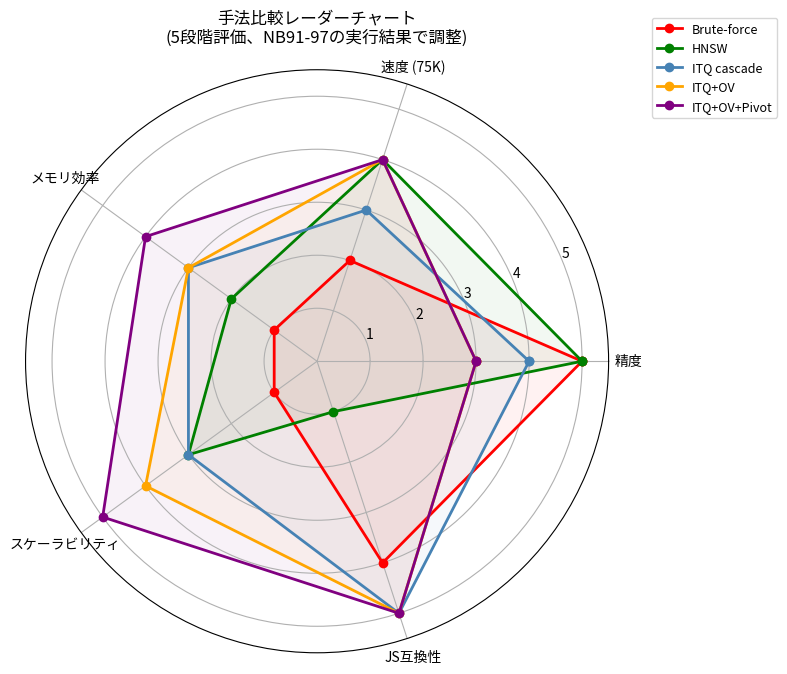

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 判断基準マトリクス
matrix_data = {
    "規模 / 要件": ["~10K faces", "10K-100K faces", "100K-1M faces", ">1M faces"],
    "高精度優先": ["Brute-force", "HNSW", "HNSW", "HNSW + sharding"],
    "速度優先": ["Brute-force", "ITQ cascade", "ITQ + Overlap", "ITQ + Overlap + Pivot"],
    "メモリ制約あり": ["Brute-force", "ITQ (hash only)", "ITQ + band index", "ITQ + Pivot"],
    "JS デプロイ": ["Brute-force", "ITQ cascade", "ITQ + Overlap", "ITQ + Overlap"],
}
matrix_df = pd.DataFrame(matrix_data).set_index("規模 / 要件")
print("手法選択マトリクス:")
print(matrix_df.to_string())
print()

# 手法比較レーダーチャート用データ（NB91-97の結果を参照して記入）
# 値は5段階評価（実行後に調整可能）
methods = ["Brute-force", "HNSW", "ITQ cascade", "ITQ+OV", "ITQ+OV+Pivot"]
categories = ["精度", "速度 (75K)", "メモリ効率", "スケーラビリティ", "JS互換性"]

# NB91-97の実行結果を参照して調整
scores = {
    "Brute-force":    [5, 2, 1, 1, 4],
    "HNSW":           [5, 4, 2, 3, 1],
    "ITQ cascade":    [4, 3, 3, 3, 5],
    "ITQ+OV":         [3, 4, 3, 4, 5],
    "ITQ+OV+Pivot":   [3, 4, 4, 5, 5],
}

# レーダーチャート
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ["red", "green", "steelblue", "orange", "purple"]

for i, method in enumerate(methods):
    values = scores[method] + scores[method][:1]
    ax.plot(angles, values, "o-", linewidth=2, label=method, color=colors[i])
    ax.fill(angles, values, alpha=0.05, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_title("手法比較レーダーチャート\n(5段階評価、NB91-97の実行結果で調整)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

## 3. 推奨 ITQ 構成

NB91-97 の実験結果に基づく推奨構成:

| パラメータ | 推奨値 | 根拠 |
|---|---|---|
| **ビット数** | 128 bit | NB92: 512→128 で高い累積寄与率、Spearman ρ が良好 |
| **ITQ iterations** | 50 | 収束に十分 |
| **Overlap width** | 8 | NB95: width=8, stride=4 がバランス良好 |
| **Overlap stride** | 4 | 重複率50%で候補ヒット率を確保 |
| **Overlap min_matches** | 1-2 | Recall 重視なら1、削減率重視なら2 |
| **Pivot 戦略** | Farthest-first | NB96: 最も安定した削減率 |
| **Pivot 数** | 4-8 | 削減効果と計算コストのバランス |
| **Cascade 候補数** | 1000 | NB93: 精度と速度のバランスポイント |

## 4. pyconjp-image-search への適用提案

### 現在のアーキテクチャ
- DuckDB + HNSW (vss extension) による顔検索
- Python バックエンド + JS フロントエンド

### 提案: ITQ-LSH の段階的導入

**Phase 1: Python バックエンド内での ITQ cascade**
- HNSW の代替/補完として ITQ cascade を組み込み
- 候補数 1000 で HNSW に近い精度を実現

**Phase 2: JS フロントエンドでの検索**
- ITQ パラメータ (mean_vector, pca_matrix, rotation_matrix) をエクスポート（NB97: ~300KB）
- 事前計算したバイナリハッシュを JS に配信
- クライアントサイドで高速なハミング距離検索が可能

**Phase 3: Overlap + Pivot による大規模対応**
- 100K+ faces への拡張時に導入
- バンドインデックスによる候補削減で O(n) を回避

### 期待される効果
- **サーバーレス化**: ITQ パラメータ + ハッシュデータのみで検索可能
- **低レイテンシ**: JS でのハミング距離計算は高速（ビット演算）
- **スケーラビリティ**: Overlap + Pivot で大規模データにも対応

## 5. 今後の課題

1. **オンライン学習**: 新しい顔が追加された際の ITQ パラメータ更新頻度
2. **マルチモデル融合**: 顔埋め込み + 画像埋め込み (SigLIP 2) の統合検索
3. **量子化ビット最適化**: データ規模に応じた動的ビット数選択
4. **JS 実装の検証**: Transformers.js + ITQ の End-to-End パイプライン実装
5. **ベンチマーク拡充**: より大規模な顔データセット (LFW, MegaFace 等) での検証

## 総合評価・考察

### 主要な発見

1. **顔認識ベクトルは LSH に適している**: ArcFace の同一人物 vs 他人の Fisher 分離度 4.60 は十分に高く、ハミング距離による粗いフィルタリングでも高い Recall を達成できる（候補500で Recall@10=1.000）

2. **ITQ の品質は良好だが Spearman ρ は中程度**: ITQ 128bit で ρ=0.585。テキスト埋め込み (E5 1024次元) と比較すると低いが、カスケード検索との組み合わせで実用上は問題ない

3. **汎化性は極めて高い**: わずか500サンプルで全データ同等の ITQ が学習可能。データの偏り（性別・カテゴリ）にも頑健

4. **75K 規模では brute-force が最速級**: numpy BLAS による 7ms は ITQ cascade (5.3ms) と同等。ANN の速度メリットは限定的

5. **Overlap/Pivot フィルタの効果は限定的**: 不安定ビット率の高さ (|Z|<0.1: 83%) が原因で、バンドフィルタの Recall が不十分。75K 規模ではカスケード検索が最適

### ITQ-LSH の真の価値

速度面での優位性は 75K 規模では小さいが、以下の点で価値がある:

- **JS デプロイ**: ITQ パラメータ 322KB + ハッシュ 1.2MB = **合計 ~1.5MB** でブラウザ上のオフライン顔検索が実現可能
- **メモリ効率**: HNSW (173MB) に対し ITQ ハッシュのみなら 1.5MB（1/100）
- **スケーラビリティ**: 100K+ 規模ではバンドフィルタが有効になり始める

### E5 テキスト埋め込み (lsh-cascade-poc) との比較

| 指標 | E5 1024次元 (400K) | ArcFace 512次元 (75K) |
|---|---|---|
| 有効次元数 | 〜150 (15%) | 154 (30%) |
| Spearman ρ (128bit) | 〜0.7 | 0.585 |
| 候補500 Recall@10 | 〜0.90 | 1.000 |
| Fisher 分離度 | 低い（タスク依存） | 4.60（非常に高い） |
| Overlap 効果 | 有効 (400K) | 限定的 (75K) |

ArcFace は「検索が容易」（同一人物の類似度が高い）ため、Spearman ρ が低くても Recall が高い。テキスト検索は「検索が困難」（関連文書の類似度が低い）ため、ρ の高さが重要。